In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from scipy.stats import binomtest, ttest_ind, chi2_contingency, chisquare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from pandas.api.types import CategoricalDtype

df = pd.read_csv("train_data.csv")
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
train_set.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
91348,108635,15606267,Wilson,622,France,Female,35.0,7,98640.74,2,1.0,1.0,110457.99,1
2636,147941,15644891,Pirozzi,752,France,Female,32.0,2,0.00,1,1.0,0.0,159843.24,0
117007,88744,15702464,Watson,710,France,Male,31.0,4,0.00,3,0.0,0.0,160548.66,1
100279,125789,15701605,L?,704,Germany,Male,46.0,4,138912.17,1,0.0,1.0,141804.78,1
34835,135997,15757577,Hs?,675,Germany,Female,51.0,8,143390.51,1,1.0,0.0,168034.90,1


Avant de commencer il faut s'assurer de voir si il n'y a pas de valeur manquante.

In [3]:
df.isnull().sum()

ID                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Il n'y a pas de valeur manquante. Passons à l'analyse de la target.

In [4]:
train_set["Exited"].value_counts()

Exited
0    90564
1    24299
Name: count, dtype: int64

On voit que les deux classes de la target sont assez désiquilibré et c'est pour cette raison qu'on utilisera la métrique f1_score. On va d'abords utiliser un modéle de régréssion logistique pour un premier modéle.

##I) Définition des variables

•   Customer ID : Un identifiant unique pour chaque client (discret). Inutile pour le modéle.

•   Surname : Le nom de famille du client (discret). Inutile pour le modéle.

•   Credit Score : Une valeur numérique représentant le score de crédit du client (continue)

•   Geography : Le pays où réside le client (France, Spain ou Germany) (discret)

•   Gender : Le genre du client (Male or Female) (discret)

•   Age : L’âge du client (C'est une variable discréte mais qu'on va traiter comme une variable continue)

•   Tenure : Le nombre d’années pendant lesquelles le client est avec la banque (discret)

•   Balance : Le solde du compte du client (continue)

•   NumOfProducts : Le nombre de produits bancaires utilisés par le client (par exemple, compte d’épargne, carte de crédit) (discret)

•   HasCrCard : Si le client possède une carte de crédit (1 = oui, 0 = non) (discret)

•   IsActiveMember : Si le client est un membre actif (1 = oui, 0 = non) (discret)

•   EstimatedSalary : Le salaire estimé du client (continue)

•   Exited : Si le client a résilié (1 = oui, 0 = non) (discret)

•   Pour la définition des lignes, c'est les clients de la banque.

##II) Analyse statistiques

#II.1) Analyse univarié

1) Analyse des variables discrétes

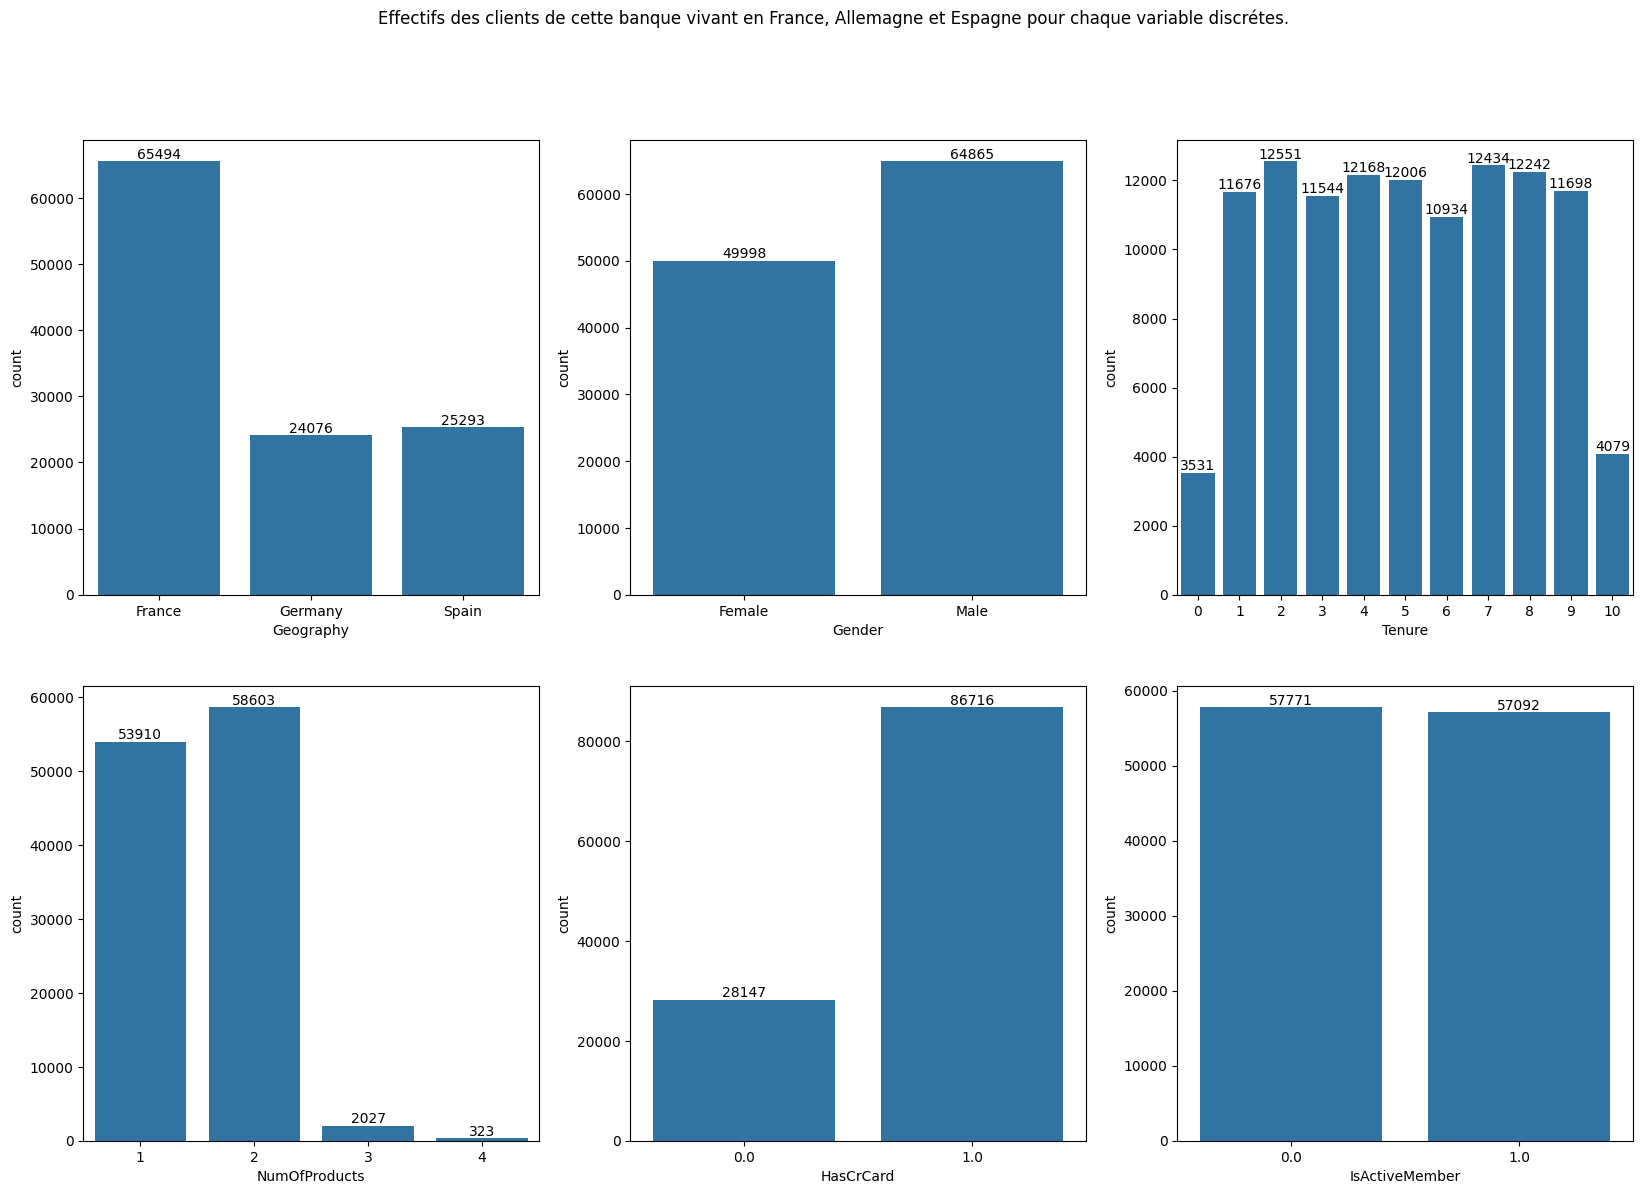

In [5]:
fig, ax = plt.subplots(2, 3)
plt.suptitle(
    "Effectifs des clients de cette banque vivant en France, Allemagne et Espagne pour chaque variable discrétes."
)
fig.set_size_inches(20, 13)
sns.countplot(data=train_set, x="Geography", ax=ax[0, 0])
sns.countplot(data=train_set, x="Gender", ax=ax[0, 1])
sns.countplot(data=train_set, x="Tenure", ax=ax[0, 2])
sns.countplot(data=train_set, x="NumOfProducts", ax=ax[1, 0])
sns.countplot(data=train_set, x="HasCrCard", ax=ax[1, 1])
sns.countplot(data=train_set, x="IsActiveMember", ax=ax[1, 2])
for ax_i in ax:
    for ax_ii in ax_i:
        for container in ax_ii.containers:
            ax_ii.bar_label(container)
plt.show()

a) Geography

Nous observons qu'il y a une majorité de client qui vive en France et qu'il y a un nombre similaire de client qui vive en allemagne et en Espagne. On va essayer de tester la différences de nombre de client entre l'Espagne et l'Allemagne avec un test d'hypothése. On peut émettre comme hypothése que la banque est peut-être une banque Française mais on ne peut pas le prouver avec nos données.

b) Genre

On remarque qu'il y a plus d'homme que de femme dans cette banque. Pour être sur que cette différence est généralisable sur toutes la population, on va faire un test d'hypothése.

c) Tenure

On remarque que pour des tenures de 0 et 10 on a moins de clients que pour les autres années mais cela peut s'expliquer par le fait que pour la tenure égale à 10, l'étude à commencer durant l'année en cours et pour une valeur de 0, l'année en cours n'ai pas terminé. Pour le reste des tenures, les nombres de clients fluctue mais reste relativement constant.

d) Nombre de produits

On a plus de clients qui ont 2 produit que 1 produit même si les effectifs sont similaires. On va essayer de tester cette similitudes avec un test d'hypothése. On observe qu'il y a vraiment peu de client qui ont 3 et 4 produits. On peut émettre l'hypothése que la banque à une mauvaise stratégie marketing concernant certains produits. Cela ne peut pas être expliqué par nos donnée.

e) Possession d'une carte de crédit

Il y a clairement plus de clients possédant une carte de crédit. Ceci s'explique que beaucoup de clients ont besoin de payer à crédits. 

f) Status d'activité

On observe qu'il y a un nombre similaire de client actifs que inactifs. On vérifiera cettte similitudes avec un test d'hypothése.

a) Geography

Maintenant on va faire des tests d'hypothéses afin de généraliser les observations précédentes à toutes la population. On va d'abords vérifier que le nombre de clients vivant en Allemagne n'est pas le même que ceux qui vive en Espagne.

In [6]:
print("H0: Il y a le même nombre de client vivant en Allemagne et en Espagne.")

alpha = 0.02

data_test = train_set.query("`Geography` != 'France'")

k = data_test["Geography"].value_counts()["Spain"]

n = len(data_test)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a le même nombre de client vivant en Allemagne et en Espagne.
Nous avons assez d'évidence pour rejeter H0.


Comme on a rejeter H0, on peut dire avec un seuil alpha de 2% que le nombre de client vivant en Allemagne et en Espagne est différent. 

b) Genre

On va essayer de prouver que la différence observer est bien significatif.

In [7]:
print("H0: Il y a le même nombre de femmes que d'homme.")

alpha = 0.02

k = train_set["Gender"].value_counts()["Female"]

n = len(train_set)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a le même nombre de femmes que d'homme.
Nous avons assez d'évidence pour rejeter H0.


Sans surprise l'hypothése H0 à été rejeter. On peut donc dire avec une seuil alpha de 2% qu'il y a bien plus d'hommes que de femmes dans cette banque. 

c) Nombre de produit

On va essayer de tester la différence entre le nombre de client qui ont 1 et ceux qui ont 2 produit.

In [8]:
print("H0: Il y a le même nombre de clients qui ont 1 et 2 produit.")

alpha = 0.02

data_test = train_set.query("`NumOfProducts` < 3")

k = data_test["NumOfProducts"].value_counts()[1]

n = len(data_test)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a le même nombre de clients qui ont 1 et 2 produit.
Nous avons assez d'évidence pour rejeter H0.


Comme on a rejeter H0 on peut donc dire avec un seuil alpha de 2% que le nombre de clients qui ont 1 et 2 produit est différent. 

d) Possession d'une carte de crédit

On va tester si la grande différence entre les clients qui posséde une carte de crédit et ceux qui n'en posséde pas est généralisable sur toutes la population.

In [9]:
print(
    "H0: Il y a le même nombre de client qui posséde une carte de crédit que ceux qui n'en posséde pas."
)

alpha = 0.02

k = train_set["HasCrCard"].value_counts()[0]

n = len(train_set)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a le même nombre de client qui posséde une carte de crédit que ceux qui n'en posséde pas.
Nous avons assez d'évidence pour rejeter H0.


Sans surprise l'hypothése H0 est rejeter. On peut donc dire avec un seuil alpha de 2% qu'il y a bien plus de client qui ont une carte de crédit que ceux qui n'en ont pas.

e) Status d'activité

On va essayer de tester si il y a autant de client qui sont actif que ceux qui ne sont pas actifs.

In [10]:
print("H0: Il y a le même nombre de client actifs que inactif.")

alpha = 0.02

k = train_set["IsActiveMember"].value_counts()[0]

n = len(train_set)

p_value = binomtest(k=k, n=n).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0.")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Il y a le même nombre de client actifs que inactif.
Nous n'avons pas assez d'évidence pour rejeter H0.


Comme l'hypothése H0 n'est pas rejeter on peut donc dire que tant qu'il n'y a pas une preuve du contraire, le nombre de client actifs de cette banque est identiques à ceux qui sont inactifs.

2) Analyse des variables continues

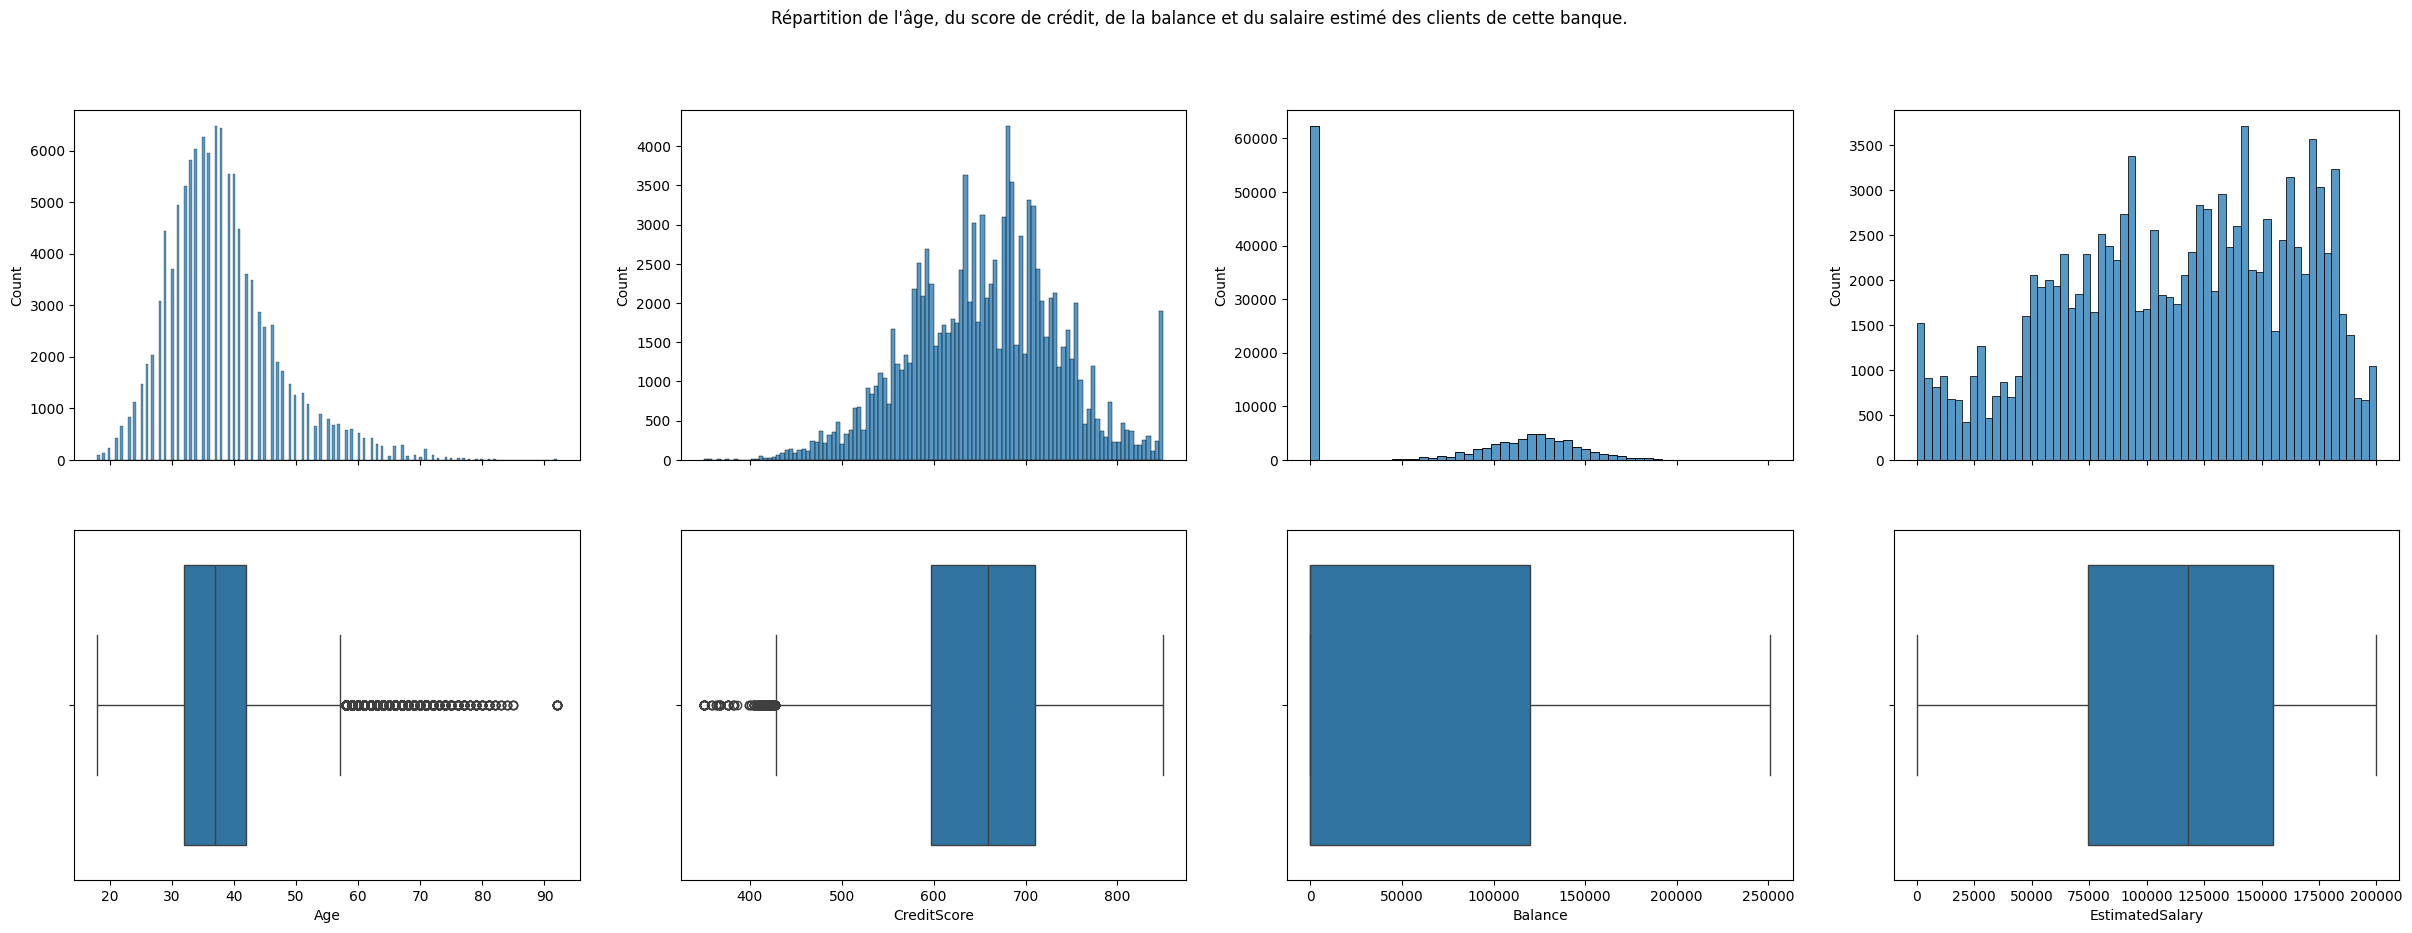

,Age,CreditScore,Balance,EstimatedSalary
count,114863.000000,114863.000000,114863.000000,114863.000000
mean,38.143017,656.504087,55624.554866,112487.446654
std,8.869733,80.183550,62825.062047,50294.787529
min,18.000000,350.000000,0.000000,11.580000
25%,32.000000,597.000000,0.000000,74564.365000
50%,37.000000,659.000000,0.000000,117832.880000
75%,42.000000,710.000000,120037.960000,154874.095000
max,92.000000,850.000000,250898.090000,199992.480000


In [11]:
fig, ax = plt.subplots(2, 4, sharex="col")
fig.set_size_inches(30, 10)
plt.suptitle(
    "Répartition de l'âge, du score de crédit, de la balance et du salaire estimé des clients de cette banque."
)
sns.histplot(data=train_set, x="Age", ax=ax[0, 0])
sns.boxplot(data=train_set, x="Age", ax=ax[1, 0])
sns.histplot(data=train_set, x="CreditScore", ax=ax[0, 1])
sns.boxplot(data=train_set, x="CreditScore", ax=ax[1, 1])
sns.histplot(data=train_set, x="Balance", ax=ax[0, 2])
sns.boxplot(data=train_set, x="Balance", ax=ax[1, 2])
sns.histplot(data=train_set, x="EstimatedSalary", ax=ax[0, 3])
sns.boxplot(data=train_set, x="EstimatedSalary", ax=ax[1, 3])
plt.show()

train_set[["Age", "CreditScore", "Balance", "EstimatedSalary"]].describe()

a) Age

On voit que la moyenne d'âge des clients de cette banque vivant en France, en Allemagne et en Espagne est de 38 ans avec un écart-type de 8.87 ans. Le minimum est de 18 ans ce sui est normale car l'âge minimum pour les trois pays pour avoir un compte bancaire. La médiane est de 37 ans. Le client le plus âgé à 92 ans qui est peut-être un client qui est décédé et il faut vérifier cela en regardant si sont compte est actif ou pas. On observe que l'âge suit une loi normale et que la plupart des clients ont entre 28 et 50 ans. On observe aussi qu'il y a des outliers à droite de la boxplot.

b) Score de crédit

Le score de crédit est une variable qui évalue la fiabilité d'un clients. Plus le score est bas, moins le client est fiable. La moyenne des score de crédit des clients de cette banque qui vive en France, en Allemagne et en Espagne est de 656.50 qui est un score plutôt moyen. L'écart-type est de 80.18. Le score minmum est de 350 et maximum est de 850 et la médiane est à 659. On voit que le score de crédit suit une loi normale et que la plupart des clients ont un score entre 550 et 750. On observe quelques outliers à gauche de la boxplot.

c) La balance 

La moyenne des balances des clients de cette banque vivant en France, en Allemagne et en Espagne est de 55624.55 euros avec un écart-type de 62825.06 euros. La balance minimum est à 0 euros, le maximum à 250898.09 euros et la médiane à 0 euros. On voit que la plupart des clients ont une balance égale à 0 et que les balance différent de 0 forme une loi normale. L'éxistence de balance égale à 0 n'est pas étrange car quand on créer un compte bancaire, la balance est de 0. Il peut avoir plusieurs raison d'avoir une balance égale à 0 et on essayera de trouver les différentes raison pour voir si il y a une relation entre ces différentes raisons et la target.

d) Le salaire

Avant d'analyser les statistiques on voit que le salaire minimum est de 11.58 euros ce qui est impossible. On voit aussi que la plupart des salaires sont trés élevé. Il y a donc plusieur types de salaire ce qui rend cette variable inutilisable. On peut quand même essayer de corriger cette variable mais on ne le fera pas pour le premier essaie.

#II.2) Analyse de chaque variable avec la target

1) Analyse des variables dicrétes en fonction de la target

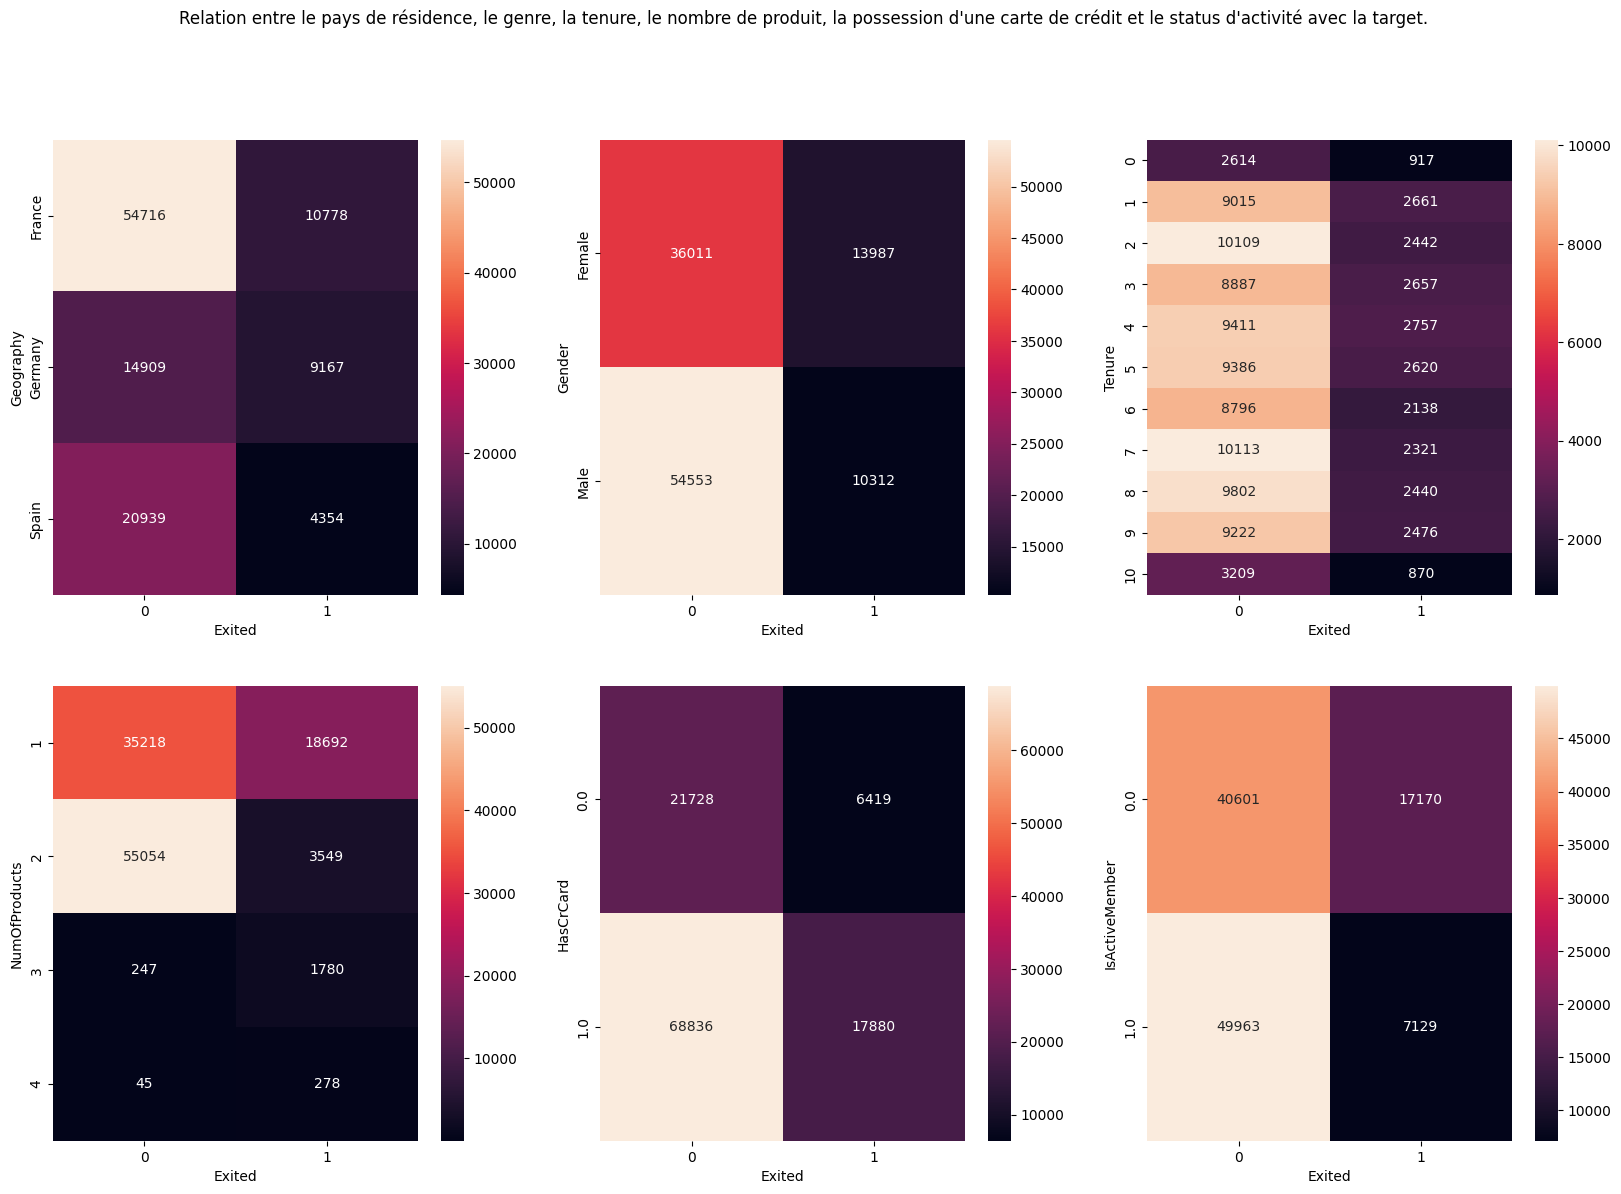

In [18]:
fig, ax = plt.subplots(2, 3)
plt.suptitle(
    "Relation entre le pays de résidence, le genre, la tenure, le nombre de produit, la possession d'une carte de crédit et le status d'activité avec la target."
)
fig.set_size_inches(20, 13)
sns.heatmap(
    pd.crosstab(train_set["Geography"], train_set["Exited"]),
    annot=True,
    fmt="d",
    ax=ax[0, 0],
)
sns.heatmap(
    pd.crosstab(train_set["Gender"], train_set["Exited"]),
    annot=True,
    fmt="d",
    ax=ax[0, 1],
)
sns.heatmap(
    pd.crosstab(train_set["Tenure"], train_set["Exited"]),
    annot=True,
    fmt="d",
    ax=ax[0, 2],
)
sns.heatmap(
    pd.crosstab(train_set["NumOfProducts"], train_set["Exited"]),
    annot=True,
    fmt="d",
    ax=ax[1, 0],
)
sns.heatmap(
    pd.crosstab(train_set["HasCrCard"], train_set["Exited"]),
    annot=True,
    fmt="d",
    ax=ax[1, 1],
)
sns.heatmap(
    pd.crosstab(train_set["IsActiveMember"], train_set["Exited"]),
    annot=True,
    fmt="d",
    ax=ax[1, 2],
)
plt.show()